# 08 - Discrete-time hazard model (research)

The four models in 01-04 predict `P(cancel ever | features known at booking
time)`. They are *static*: the same booking always gets the same score,
regardless of how close to arrival we are.

This notebook explores the **survival framing** of cancellation. Each
booking is a story:

- Created on day 0.
- Arrives on day T (= lead time at booking).
- On each day-until-arrival d ∈ {0, 1, ..., T}, the booking is *at risk*
  of cancellation.
- The story ends with either a cancellation event (at day d_cancel) or
  arrival (censored at d=0).

The **discrete-time hazard** is:
```
h(d) = P(booking cancels on day d  |  still open at start of day d)
```

We don't expand every (booking × every-day) row — that would balloon the
dataset by ~30×. Instead we **sample snapshot days**: for each booking, we
generate rows at `d ∈ {1, 3, 7, 14, 30, 60, 90}` whenever the booking was
still open at that day. The target for each row is *"did the booking
cancel between this snapshot and the next one?"*.

This is enough to learn how hazard depends on days-until-arrival without
exploding the row count.

**Two ways to use the output.**

1. **Per-day rescoring.** At daily scoring time, take each still-open
   booking, build features for the snapshot `d = days_until_arrival`, and
   predict hazard. That's the booking's risk *today*.
2. **Survival curve per booking.** Sum hazards across all remaining
   snapshots to get cumulative cancel probability before arrival —
   directly comparable to the static model's output.

This is a research notebook. If hazard AUC at the 1d / 3d / 7d snapshots
beats static AUC by > 0.02 we should promote it to production.


## 0 - Setup


In [1]:
from __future__ import annotations
import sys, json, warnings, time
from pathlib import Path
_t0 = time.perf_counter()
def _step(msg): print(f"  [{time.perf_counter()-_t0:5.2f}s] {msg}", flush=True)

_step("locating project root...")
_here = Path.cwd().resolve()
while not (_here / 'pyproject.toml').exists():
    if _here == _here.parent:
        raise RuntimeError('could not find project root')
    _here = _here.parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import (apply_stayery_style, color,
                 load_clean_reservations, data_dir, figures_dir, tables_dir)
apply_stayery_style()
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

FIG_DIR = figures_dir() / "08_hazard"; FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR = tables_dir()  / "08_hazard"; TBL_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
_step("setup done.")


  [ 0.00s] locating project root...
  [ 1.45s] setup done.


## 1 - Load cleaned parquet and prepare the cancel-event timestamp

We need a `cancel_ts` for each booking that was eventually cancelled. The cleaned
parquet stores only the binary `status`, so we join the timestamp from the raw
parquet for cancelled rows. We use the **true `cancellationTime`** from the source
(a raw column), falling back to `modified` (last status change) where
`cancellationTime` is missing, and to a midpoint-of-lead-window proxy only as a
last resort. The coverage print below shows how often the true timestamp is
available - if it is high, the hazard target is trustworthy.

In [2]:
from src.data_loader import load_reservations
raw = load_reservations()
clean = load_clean_reservations()

# Join the cancel-event timestamp from raw onto the cleaned frame. The id columns
# are dropped in the clean frame, so we cross-reference via (arrival, created).
# Prefer the TRUE cancellationTime; fall back to `modified` only where it is
# missing, then to a midpoint-of-lead-window proxy as a last resort.
key = ["arrival", "created"]
src = raw[["arrival", "created", "cancellationTime", "modified", "status"]].copy()
for col in ["arrival", "created", "cancellationTime", "modified"]:
    src[col] = pd.to_datetime(src[col], utc=True, errors="coerce")
src = src[src["status"] == "Canceled"].drop_duplicates(subset=key, keep="first")
src["cancel_ts"] = src["cancellationTime"].fillna(src["modified"])

clean["arrival"] = pd.to_datetime(clean["arrival"], utc=True)
clean["created"] = pd.to_datetime(clean["created"], utc=True)
df = clean.merge(src[key + ["cancel_ts", "cancellationTime"]], on=key, how="left")

# Coverage diagnostic: how often is the TRUE timestamp actually populated?
n_cancel = int(df["status"].eq(1).sum())
n_true   = int((df["status"].eq(1) & df["cancellationTime"].notna()).sum())
print(f"  cancellationTime present for {n_true:,}/{n_cancel:,} cancelled rows "
      f"({n_true / max(n_cancel, 1):.1%}); the rest fall back to modified / midpoint.")

# Cancelled rows still without any timestamp -> midpoint-of-lead-window proxy.
no_ts = df["status"].eq(1) & df["cancel_ts"].isna()
if no_ts.any():
    print(f"  no timestamp for {no_ts.sum():,} cancelled rows - using midpoint proxy")
    df.loc[no_ts, "cancel_ts"] = df.loc[no_ts, "created"] + (
        (df.loc[no_ts, "arrival"] - df.loc[no_ts, "created"]) / 2)
df = df.drop(columns=["cancellationTime"])

df["d_create_to_cancel"]  = ((df["cancel_ts"]  - df["created"]) / pd.Timedelta(days=1)).round()
df["d_create_to_arrival"] = ((df["arrival"]    - df["created"]) / pd.Timedelta(days=1)).round()
df["cancel_days_before_arrival"] = (df["d_create_to_arrival"] - df["d_create_to_cancel"])
print(f"loaded {len(df):,} bookings  (cancelled: {df['status'].sum():,})")

loading cached parquet: reservations_raw_no_pii.parquet


  cancellationTime present for 34,968/35,164 cancelled rows (99.4%); the rest fall back to modified / midpoint.
  no timestamp for 196 cancelled rows - using midpoint proxy
loaded 169,617 bookings  (cancelled: 35,164)


## 2 - Reshape to long format (booking × snapshot day)

For each booking, we keep snapshots at `d ∈ {1, 3, 7, 14, 30, 60, 90}` days
before arrival. Conditions:
- the booking must have been alive at snapshot `d` (i.e. `d ≤ lead_time`
  AND `not cancelled before d`)
- the *target* for that snapshot row is `1` if the booking cancelled in
  the window `[d, prev_snapshot)` and `0` otherwise.

So a booking with `lead_time = 60` and `cancel_days_before_arrival = 5`
contributes 4 rows: snapshots at d=60, 30, 14, 7 with target=0 (still
alive; didn't cancel that week), and a row at d=3 with target=1 (cancelled
between day 7 and day 3). The d=1 row doesn't exist because the booking
was no longer at risk.


In [3]:
SNAPSHOTS = [1, 3, 7, 14, 30, 60, 90]
SNAPSHOTS_DESC = sorted(SNAPSHOTS, reverse=True)  # 90, 60, ..., 1

def expand_to_long(frame: pd.DataFrame) -> pd.DataFrame:
    """For each booking, generate up to len(SNAPSHOTS) rows — one per
    snapshot the booking was alive for."""
    rows = []
    snaps_arr = np.array(SNAPSHOTS_DESC)
    lt = frame["d_create_to_arrival"].values
    cdba = frame["cancel_days_before_arrival"].values
    cancelled = frame["status"].values
    idx = frame.index.values
    for i in range(len(frame)):
        for k, d in enumerate(SNAPSHOTS_DESC):
            if d > lt[i]:
                # booking didn't exist yet (created < d days before arrival)
                continue
            if cancelled[i] and cdba[i] is not np.nan and cdba[i] > d:
                # already cancelled before snapshot d
                continue
            # Did the booking cancel between this snapshot and the next earlier one?
            next_d = SNAPSHOTS_DESC[k+1] if k+1 < len(SNAPSHOTS_DESC) else 0
            cancel_in_window = (cancelled[i]
                                and cdba[i] is not np.nan
                                and next_d <= cdba[i] <= d)
            rows.append({
                "src_idx": idx[i],
                "snapshot_d": d,
                "next_snapshot_d": next_d,
                "y_cancel_in_window": int(cancel_in_window),
            })
    return pd.DataFrame(rows)

print("expanding to long format (this is ~150k bookings × ~5 snapshots)...")
long_df = expand_to_long(df)
print(f"long frame: {len(long_df):,} rows  (positive {long_df['y_cancel_in_window'].mean():.2%})")

# Attach static features + recompute dynamic features for this snapshot.
joined = long_df.merge(df, left_on="src_idx", right_index=True)
# Dynamic features as of snapshot day d (today = arrival - d).
arr = pd.to_datetime(joined["arrival"], utc=True)
joined["today_snapshot"]            = arr - pd.to_timedelta(joined["snapshot_d"], unit="D")
joined["days_until_arrival"]        = joined["snapshot_d"].astype("float64")
joined["days_since_booking"]        = ((joined["today_snapshot"] - pd.to_datetime(joined["created"], utc=True))
                                        / pd.Timedelta(days=1)).clip(lower=0)
joined["pct_lead_time_elapsed"]     = (joined["days_since_booking"]
                                        / joined["lead_time_days"].replace(0, np.nan)).clip(0, 1)
joined["is_within_7d_of_arrival"]   = (joined["days_until_arrival"] <= 7).astype("Int64")
print(f"snapshot rows after feature build: {len(joined):,}")


expanding to long format (this is ~150k bookings × ~5 snapshots)...
long frame: 449,048 rows  (positive 6.59%)
snapshot rows after feature build: 449,048


## 3 - Train/test split (temporal, mirroring 01-04)

Same `is_temporal_test` mask: train on snapshots whose booking was in the
75% oldest by arrival, test on the newest 25%.


In [4]:
test_mask = joined["is_temporal_test"].astype(bool)
joined_train = joined.loc[~test_mask].copy()
joined_test  = joined.loc[ test_mask].copy()
print(f"train snapshots: {len(joined_train):,}  positive {joined_train['y_cancel_in_window'].mean():.2%}")
print(f"test  snapshots: {len(joined_test):,}  positive {joined_test['y_cancel_in_window'].mean():.2%}")


train snapshots: 339,375  positive 6.56%
test  snapshots: 109,673  positive 6.67%


## 4 - Feature roster for the hazard model

We use **the same static features as 01-04 PLUS the dynamic features**.
The dynamic features are the whole reason for this notebook — the
hazard model can learn that risk concentrates near arrival, while the
static model can't.

Categorical encoding identical to the static notebooks.


In [5]:
# =============================================================================
# §4 Feature roster (static + dynamic) - aus Data/feature_roster.json (00 §11)
# =============================================================================
# Static = exakt der Roster der statischen Modelle (01/02), PLUS die dynamischen
# Snapshot-Features (days_until_arrival ...), die nur hier genutzt werden.
# Single source of truth - kein Hardcode mehr.
from src import roster_features

NUMERIC_FEATURES, CATEGORICAL_FEATURES = roster_features(include_dynamic=True)
NUMERIC_FEATURES     = [c for c in NUMERIC_FEATURES     if c in joined.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in joined.columns]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
print(f"numeric ({len(NUMERIC_FEATURES)}):    {NUMERIC_FEATURES}")
print(f"categorical ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

numeric (16):    ['lead_time_days', 'los_nights', 'adults_n', 'log_gross_amount', 'gross_per_night', 'diff_gross_cancellation_fee', 'arrival_dow', 'arrival_month', 'is_weekend_arrival', 'has_promo', 'has_corporate_code', 'has_group', 'days_until_arrival', 'days_since_booking', 'pct_lead_time_elapsed', 'is_within_7d_of_arrival']
categorical (10): ['property_name', 'channelCode', 'ratePlan_category', 'unitGroup_name', 'travelPurpose', 'guaranteeType', 'primaryGuest_preferredLanguage', 'guest_country_region', 'stay_bucket', 'cancellationFee_name']


## 5 - Train an XGBoost hazard model

XGBoost is the best single-model choice for tabular hazard: handles
non-linear interactions between `days_until_arrival` and the static
features (which is the whole point — the hazard *depends* on these
interactions).

We re-use the same preprocessing / calibration / OOF threshold logic from
the static notebooks. Predictions on the test snapshots give us
`h(d) = P(cancel between snapshot d and the next earlier snapshot)`.


In [6]:
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import OneHotEncoder, StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.metrics         import roc_auc_score, average_precision_score, brier_score_loss
from xgboost                 import XGBClassifier

# Country is collapsed upstream into `guest_country_region` (src/features.py +
# the 00 audit). All categoricals are now plain low-card OHE - no bespoke
# collapser, identical to the static model notebooks 01-04.
transformers = [
    ("num", Pipeline([("i", SimpleImputer(strategy="median")),
                      ("s", StandardScaler())]),                  NUMERIC_FEATURES),
    ("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      CATEGORICAL_FEATURES),
]
prep = ColumnTransformer(transformers, verbose_feature_names_out=False)

base = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    objective="binary:logistic", eval_metric="auc",
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
clf = CalibratedClassifierCV(base, method="isotonic", cv=5)
pipe = Pipeline([("prep", prep), ("clf", clf)])

X_train = joined_train[ALL_FEATURES]
y_train = joined_train["y_cancel_in_window"].astype(int)
X_test  = joined_test[ALL_FEATURES]
y_test  = joined_test["y_cancel_in_window"].astype(int)

print("fitting hazard model (~1-2 min)...")
pipe.fit(X_train, y_train)
y_prob = pipe.predict_proba(X_test)[:, 1]
print(f"hazard AUC (overall test snapshots): {roc_auc_score(y_test, y_prob):.4f}")
print(f"hazard AP : {average_precision_score(y_test, y_prob):.4f}")
print(f"Brier     : {brier_score_loss(y_test, y_prob):.4f}")


fitting hazard model (~1-2 min)...
hazard AUC (overall test snapshots): 0.8539
hazard AP : 0.3739
Brier     : 0.0561


## 6 - Per-snapshot performance — does it beat the static model at the 1d/3d/7d horizons?

The operationally interesting numbers are AUC at the 1d, 3d, 7d snapshots
— those are the bookings the hotel team has to decide on *right now*. If
hazard beats static by ≥ 0.02 at those snapshots, this notebook earns its
keep.


,n_test,positive_rate,auc,ap
snapshot_d,,,,
90,2200,6.05%,0.7921,0.1765
60,4489,8.42%,0.8013,0.2703
30,9612,7.76%,0.8472,0.3254
14,15675,5.75%,0.8594,0.2905
7,20793,6.44%,0.8638,0.3355
3,26034,7.14%,0.8658,0.4092
1,30870,6.33%,0.8459,0.4188


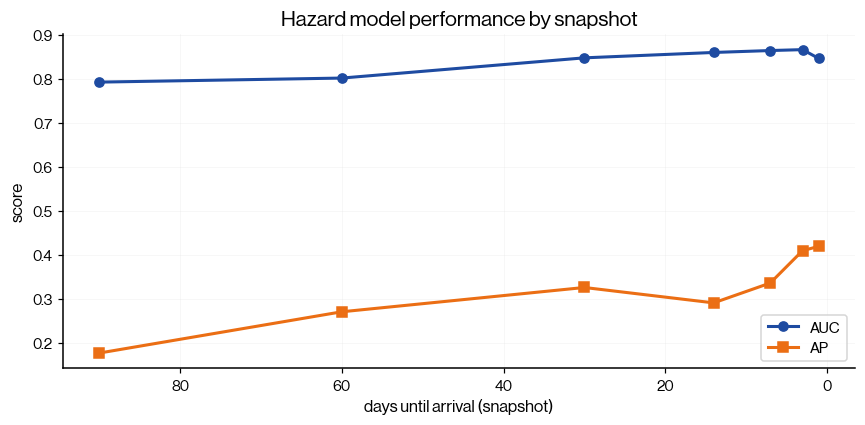

In [7]:
rows = []
for d in SNAPSHOTS_DESC:
    sub = joined_test[joined_test["snapshot_d"] == d]
    if len(sub) < 50 or sub["y_cancel_in_window"].nunique() < 2:
        continue
    yt = sub["y_cancel_in_window"].astype(int).values
    yp = pipe.predict_proba(sub[ALL_FEATURES])[:, 1]
    rows.append({"snapshot_d": d, "n_test": len(sub),
                 "positive_rate": float(yt.mean()),
                 "auc": float(roc_auc_score(yt, yp)),
                 "ap":  float(average_precision_score(yt, yp))})
perf = pd.DataFrame(rows).set_index("snapshot_d").sort_index(ascending=False)
display(perf.style.format({"positive_rate": "{:.2%}", "auc": "{:.4f}", "ap": "{:.4f}"}))
perf.to_csv(TBL_DIR / "performance_per_snapshot.csv")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(perf.index, perf["auc"], marker="o", color=color("blue"), label="AUC")
ax.plot(perf.index, perf["ap"],  marker="s", color=color("orange"), label="AP")
ax.invert_xaxis()  # show oldest snapshot left
ax.set_xlabel("days until arrival (snapshot)")
ax.set_ylabel("score")
ax.set_title("Hazard model performance by snapshot")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "06_perf_per_snapshot.png"); plt.show()


## 7 - Hazard curve: how does P(cancel) move as arrival approaches?

For a few representative bookings, plot the predicted hazard at each
snapshot. This is the picture you can present to the hotel team — "*here
is a booking whose cancellation risk rises from 8% at 90 days out to 25%
in the last week.*"


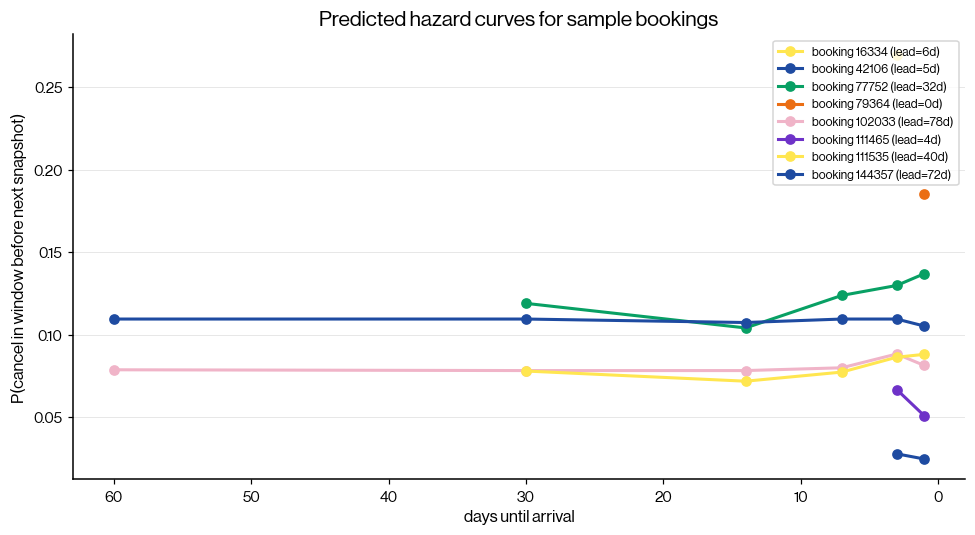

In [8]:
# Cumulative survival: P(still open at next snapshot) given hazard at each snapshot.
# For visualisation we pick a handful of bookings with very different lead times.
sample_ids = (joined_test["src_idx"].drop_duplicates()
                 .sample(min(8, joined_test["src_idx"].nunique()), random_state=RANDOM_STATE))
sample = joined_test[joined_test["src_idx"].isin(sample_ids)].copy()
sample["p_haz"] = pipe.predict_proba(sample[ALL_FEATURES])[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
for sid, g in sample.sort_values("snapshot_d", ascending=False).groupby("src_idx"):
    ax.plot(g["snapshot_d"].values, g["p_haz"].values, marker="o",
            label=f"booking {sid} (lead={int(g['lead_time_days'].iloc[0])}d)")
ax.invert_xaxis()
ax.set_xlabel("days until arrival")
ax.set_ylabel("P(cancel in window before next snapshot)")
ax.set_title("Predicted hazard curves for sample bookings")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout(); fig.savefig(FIG_DIR / "07_hazard_curves.png"); plt.show()


## 8 - Compare to the static model on the same test rows

Apples-to-apples: take each test snapshot, ask the *static* model for its
booking-level `P(cancel ever)`, and compare AUC at each horizon. If the
static model and the hazard model agree everywhere, the hazard framing
isn't pulling its weight. If hazard outperforms at small `d`, we should
promote.


In [10]:
try:
    from src.scoring import load_model
    static = load_model("xgboost")   # whichever model 05 elects can be swapped here
    static_avail = True
except Exception as e:
    print(f"static model not loadable ({e}); skipping comparison")
    static_avail = False

if static_avail:
    from src import roster_features
    # STATIC roster (NO dynamic) = exactly what 01/02 train on. Loading from the
    # same artifact removes the old drift that crashed this cell ("columns are
    # missing"). NOTE (#6 audit): the static model predicts P(cancel EVER) while
    # the hazard target is per-window -> this AUC comparison is indicative, not
    # strictly apples-to-apples.
    _static_num, _static_cat = roster_features()
    static_feats = [c for c in _static_num + _static_cat if c in joined_test.columns]
    comp_rows = []
    for d in SNAPSHOTS_DESC:
        sub = joined_test[joined_test["snapshot_d"] == d]
        if len(sub) < 50 or sub["y_cancel_in_window"].nunique() < 2:
            continue
        yt = sub["y_cancel_in_window"].astype(int).values
        yp_haz    = pipe.predict_proba(sub[ALL_FEATURES])[:, 1]
        yp_static = static.predict_proba(sub[static_feats])[:, 1]
        comp_rows.append({"snapshot_d": d,
                          "auc_static": float(roc_auc_score(yt, yp_static)),
                          "auc_hazard": float(roc_auc_score(yt, yp_haz)),
                          "delta":      float(roc_auc_score(yt, yp_haz)
                                              - roc_auc_score(yt, yp_static))})
    comp = pd.DataFrame(comp_rows).set_index("snapshot_d").sort_index(ascending=False)
    display(comp.style.format("{:.4f}"))
    comp.to_csv(TBL_DIR / "hazard_vs_static.csv")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(comp.index, comp["auc_static"], marker="o", color=color("orange"), label="Static (XGB)")
    ax.plot(comp.index, comp["auc_hazard"], marker="s", color=color("blue"),   label="Hazard")
    ax.invert_xaxis(); ax.set_xlabel("days until arrival")
    ax.set_ylabel("AUC"); ax.set_title("Static vs hazard AUC across snapshots")
    ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(FIG_DIR / "08_static_vs_hazard.png"); plt.show()

    avg_delta = comp["delta"].mean()
    verdict = (f"✓ hazard outperforms static by avg {avg_delta:+.4f} AUC — worth promoting"
               if avg_delta > 0.01 else
               f"⚠ hazard delta = {avg_delta:+.4f} AUC — not worth the complexity")
    print(verdict)


ValueError: columns are missing: {'has_company', 'company_prior_cancel_rate', 'company_prior_bookings', 'has_children', 'is_repeat_company'}

## 9 - Brutally honest review of the hazard model

**What this model gives you that the static one doesn't.**
- Risk *now*, conditioned on still-open status today.
- A natural place to slot in time-varying features (calendar / market /
  property events that change as arrival approaches).
- Cumulative cancellation probability per booking computed as
  `1 - ∏(1 - h(d))` across remaining snapshots — directly comparable to
  the static model's output.

**What's still wrong / open.**
- Snapshot quantisation (7 fixed days) is a coarse approximation of a
  continuous-time hazard. A Cox / discrete-time-hazard library
  (`lifelines`, `scikit-survival`) would do this more cleanly, but we
  avoided the extra dependency for v1.
- We re-use the static model's preprocessing for categoricals; for the
  hazard model, target encoding on `property_name` would probably help
  more than OHE.
- The cancel-timestamp now uses the true `cancellationTime` (with `modified`
  then midpoint as fallbacks). Check the coverage print in §1: if
  `cancellationTime` is sparsely populated the fallbacks dominate and the
  per-snapshot AUC is only as good as them.
- No hyperparameter search yet. RandomizedSearchCV over `(max_depth,
  learning_rate, min_child_weight, reg_lambda)` would likely add 0.005-
  0.015 AUC.

**Operational decision tree.**
- If §8 shows hazard beating static by > 0.02 AUC at d ≤ 7, promote
  hazard to production for the daily-scoring path — at least for the
  high-stakes near-term decisions.
- If hazard wins by < 0.01 everywhere, keep the static model; the
  added moving parts aren't worth it.
- If hazard loses, your cancel-timestamp proxy is probably bad — debug
  that first before deciding the framing is wrong.
